# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test3 smoothing

Notebook equivalent of `tests/6_mceq/test3_smoothing.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `mceq` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `mceq` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree, missing optional dependencies, or unavailable external model data.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test3_smoothing"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "6_mceq" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\6_mceq\test3_smoothing.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `mceq` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\mceq\test3_smoothing


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_gaussian_kernel_is_normalized`

**What is checked:** Gaussian kernel is normalized behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: 1.0.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [4]:
run_notebook_test(TEST_MODULE.test_gaussian_kernel_is_normalized)


Running test_gaussian_kernel_is_normalized ...
kernel shape: torch.Size([17])
kernel sum: 0.9999999999999999
------------------------------------------------------------------------------------------
PASSED: test_gaussian_kernel_is_normalized


## Test: `test_gaussian_kernel_rejects_non_positive_sigma`

**What is checked:** Gaussian kernel rejects non positive sigma behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_gaussian_kernel_rejects_non_positive_sigma)


Running test_gaussian_kernel_rejects_non_positive_sigma ...
------------------------------------------------------------------------------------------
PASSED: test_gaussian_kernel_rejects_non_positive_sigma


## Test: `test_smooth_flux_gaussian_preserves_shape`

**What is checked:** Smooth flux gaussian preserves shape behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_smooth_flux_gaussian_preserves_shape)


Running test_smooth_flux_gaussian_preserves_shape ...
flux_noisy shape : torch.Size([300, 5])
flux_smooth shape: torch.Size([300, 5])
------------------------------------------------------------------------------------------
PASSED: test_smooth_flux_gaussian_preserves_shape


## Test: `test_smooth_log_moving_average_preserves_shape`

**What is checked:** Smooth log moving average preserves shape behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_smooth_log_moving_average_preserves_shape)


Running test_smooth_log_moving_average_preserves_shape ...
flux_noisy shape : torch.Size([300, 5])
flux_smooth shape: torch.Size([300, 5])
------------------------------------------------------------------------------------------
PASSED: test_smooth_log_moving_average_preserves_shape


## Test: `test_smooth_flux_none_returns_same_values`

**What is checked:** Smooth flux none returns same values behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: 0.0.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_smooth_flux_none_returns_same_values)


Running test_smooth_flux_none_returns_same_values ...
max difference: 0.0
------------------------------------------------------------------------------------------
PASSED: test_smooth_flux_none_returns_same_values


## Test: `test_smooth_flux_gaussian_wrapper`

**What is checked:** Smooth flux gaussian wrapper behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_smooth_flux_gaussian_wrapper)


Running test_smooth_flux_gaussian_wrapper ...
flux_smooth shape: torch.Size([300, 5])
------------------------------------------------------------------------------------------
PASSED: test_smooth_flux_gaussian_wrapper


## Test: `test_smooth_flux_spline_alias_wrapper`

**What is checked:** Smooth flux spline alias wrapper behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [10]:
run_notebook_test(TEST_MODULE.test_smooth_flux_spline_alias_wrapper)


Running test_smooth_flux_spline_alias_wrapper ...
flux_smooth shape: torch.Size([300, 5])
------------------------------------------------------------------------------------------
PASSED: test_smooth_flux_spline_alias_wrapper


## Test: `test_compute_depth_derivative_shape`

**What is checked:** Compute depth derivative shape behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_compute_depth_derivative_shape)


Running test_compute_depth_derivative_shape ...
dPhi_dX shape: torch.Size([300, 5])
------------------------------------------------------------------------------------------
PASSED: test_compute_depth_derivative_shape


## Test: `test_compute_depth_derivative_positive_for_clean_flux`

**What is checked:** Compute depth derivative positive for clean flux behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [12]:
run_notebook_test(TEST_MODULE.test_compute_depth_derivative_positive_for_clean_flux)


Running test_compute_depth_derivative_positive_for_clean_flux ...
min dPhi_dX: 2.6170942938709607e-08
max dPhi_dX: 0.015826941955376456
------------------------------------------------------------------------------------------
PASSED: test_compute_depth_derivative_positive_for_clean_flux


## Test: `test_compute_depth_derivative_matches_analytic_clean_flux`

**What is checked:** Compute depth derivative matches analytic clean flux behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [13]:
run_notebook_test(TEST_MODULE.test_compute_depth_derivative_matches_analytic_clean_flux)


Running test_compute_depth_derivative_matches_analytic_clean_flux ...
max relative error derivative: 7.066062613803558e-07
------------------------------------------------------------------------------------------
PASSED: test_compute_depth_derivative_matches_analytic_clean_flux


## Test: `test_positive_only_clips_negative_derivative`

**What is checked:** Positive only clips negative derivative behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [14]:
run_notebook_test(TEST_MODULE.test_positive_only_clips_negative_derivative)


Running test_positive_only_clips_negative_derivative ...
min clipped derivative: 0.0
max clipped derivative: 0.0
------------------------------------------------------------------------------------------
PASSED: test_positive_only_clips_negative_derivative


## Test: `test_smooth_and_differentiate_flux_shapes`

**What is checked:** Smooth and differentiate flux shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [15]:
run_notebook_test(TEST_MODULE.test_smooth_and_differentiate_flux_shapes)


Running test_smooth_and_differentiate_flux_shapes ...
flux_smooth shape: torch.Size([300, 5])
dPhi_dX shape    : torch.Size([300, 5])
------------------------------------------------------------------------------------------
PASSED: test_smooth_and_differentiate_flux_shapes


## Test: `test_invalid_smoothing_method_raises`

**What is checked:** Invalid smoothing method raises behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [16]:
run_notebook_test(TEST_MODULE.test_invalid_smoothing_method_raises)


Running test_invalid_smoothing_method_raises ...
------------------------------------------------------------------------------------------
PASSED: test_invalid_smoothing_method_raises


## Test: `test_invalid_flux_shape_raises`

**What is checked:** Invalid flux shape raises behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [17]:
run_notebook_test(TEST_MODULE.test_invalid_flux_shape_raises)


Running test_invalid_flux_shape_raises ...
------------------------------------------------------------------------------------------
PASSED: test_invalid_flux_shape_raises


## Plot: `plot_smoothing_one_energy()`

**What is checked:** Smoothing one energy behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_smoothing_one_energy()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_smoothing_one_energy_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_smoothing_one_energy() ...

Plot smoothing for E = 5.0 GeV
Saved plot: V:\output\test\mceq\test3_smoothing\plot_smoothing_one_energy_figure_001.png


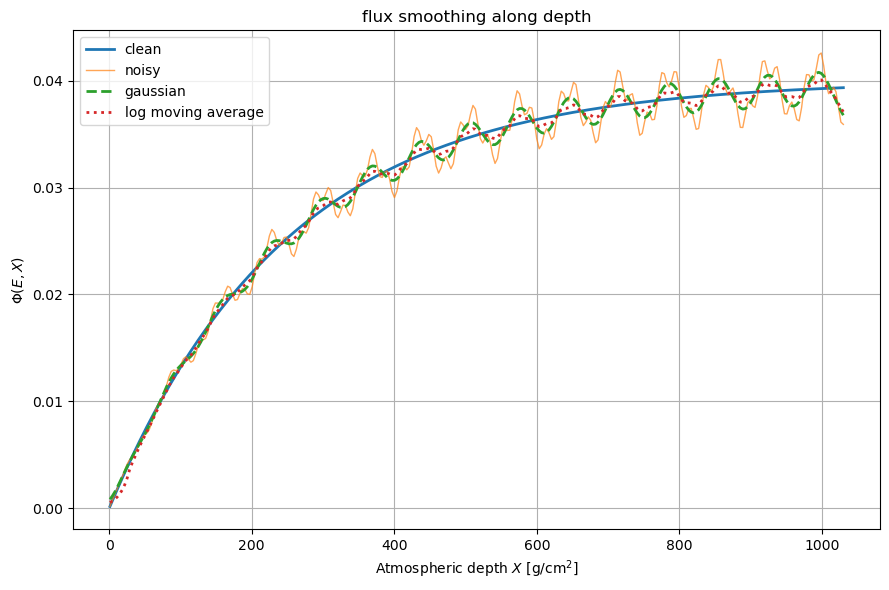

PASSED: plot_smoothing_one_energy()


In [18]:
run_notebook_call('plot_smoothing_one_energy()', lambda: TEST_MODULE.plot_smoothing_one_energy())


## Plot: `plot_derivative_one_energy()`

**What is checked:** Derivative one energy behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_derivative_one_energy()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_derivative_one_energy_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_derivative_one_energy() ...

Plot derivative for E = 5.0 GeV
Saved plot: V:\output\test\mceq\test3_smoothing\plot_derivative_one_energy_figure_001.png


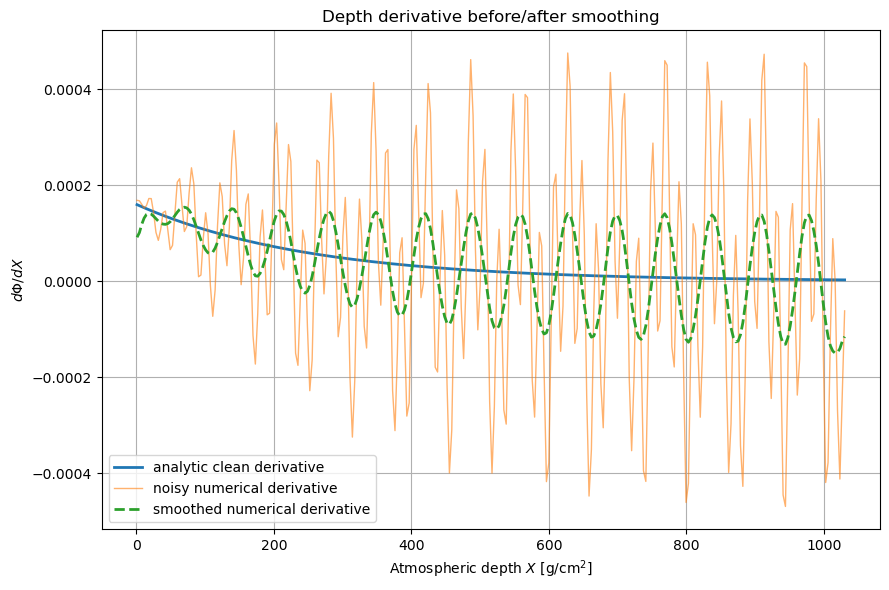

PASSED: plot_derivative_one_energy()


In [19]:
run_notebook_call('plot_derivative_one_energy()', lambda: TEST_MODULE.plot_derivative_one_energy())


## Plot: `plot_positive_only_effect()`

**What is checked:** Positive only effect behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_positive_only_effect()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_positive_only_effect_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_positive_only_effect() ...

Positive-only effect for E = 5.0 GeV
raw min: -0.0009426472462346876
positive-only min: 0.0
Saved plot: V:\output\test\mceq\test3_smoothing\plot_positive_only_effect_figure_001.png


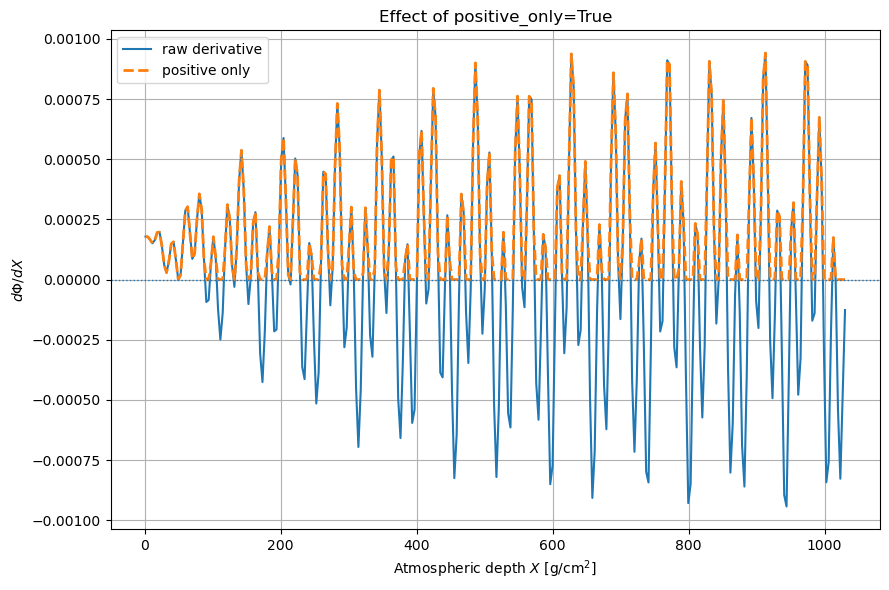

PASSED: plot_positive_only_effect()


In [20]:
run_notebook_call('plot_positive_only_effect()', lambda: TEST_MODULE.plot_positive_only_effect())


## Plot: `plot_all_energies_smoothing_ratio()`

**What is checked:** All energies smoothing ratio behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_all_energies_smoothing_ratio()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_all_energies_smoothing_ratio_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_all_energies_smoothing_ratio() ...
Saved plot: V:\output\test\mceq\test3_smoothing\plot_all_energies_smoothing_ratio_figure_001.png


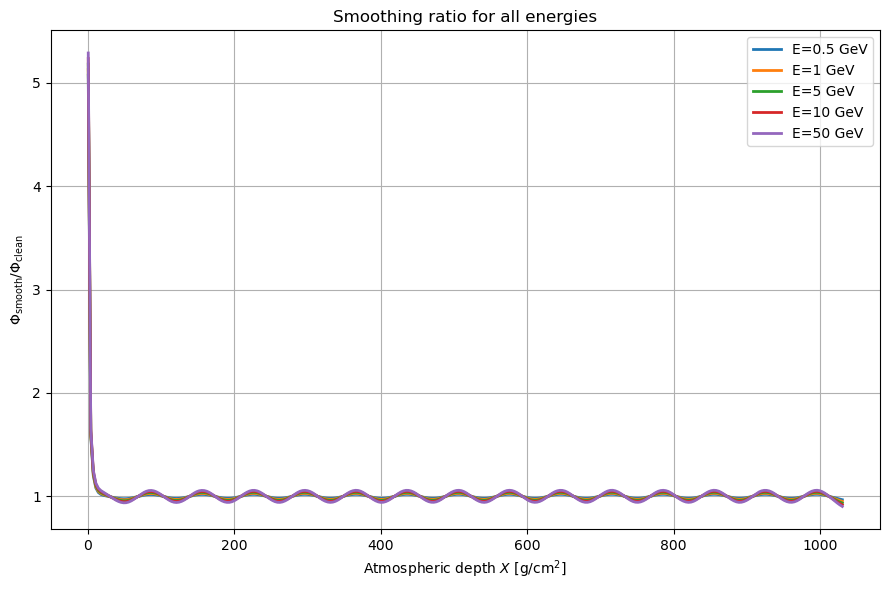

PASSED: plot_all_energies_smoothing_ratio()


In [21]:
run_notebook_call('plot_all_energies_smoothing_ratio()', lambda: TEST_MODULE.plot_all_energies_smoothing_ratio())
